# Predicting Employee Attrition

In this project, we're going to build a model to predict whether an employee is likely to leave the company. We'll use a dataset with information like their job role, satisfaction level, and overtime status to train a Logistic Regression model.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Step 1: Getting the Data Ready

First, we need to clean up our dataset.

* **Splitting X and y:** We'll separate our data into two parts: `X` (the features we'll use to make predictions) and `y` (the outcome we want to predict, which is 'Attrition').
* **Dropping Useless Columns:** We're removing columns that don't add any real information, like `EmployeeNumber` or `StandardHours`, since they are the same for everyone.

In [27]:
# read the csv file
df = pd.read_csv('Employee-Attrition.csv')
print(df.head())


   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [28]:
# split data into X and y
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# remove useless columns
X = X.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

In [29]:
print(X.columns)

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


### Turning Text into Numbers

Our machine learning model only understands numbers, so we need to convert all the text columns.

* **LabelEncoder:** We use this for columns with only two options (like 'Yes'/'No' or 'Male'/'Female') and turn them into 0s and 1s.
* **OneHotEncoder:** For columns with more than two options (like 'Department' or 'JobRole'), this creates a new column for each category, which helps the model understand them without thinking one is "bigger" or "more important" than another.

In [30]:
# change text to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
X['OverTime'] = le.fit_transform(X['OverTime'])
X['Gender'] = le.fit_transform(X['Gender'])

In [31]:
print(y)

[1 0 1 ... 0 0 0]


In [32]:
# convert other text columns to numbers
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

## Step 2: Splitting the Data

To check if our model is actually good, we can't test it on the same data we used to train it. That would be like giving a student the answers to a test before they take it.

* **Training Set (80%):** This is the data the model learns from.
* **Testing Set (20%):** This is new data the model has never seen. We use it at the end to see how accurate our model really is.

We also **scale the data** to make sure all features are on a similar scale, which helps the model learn more effectively.

In [33]:
from sklearn.model_selection import train_test_split
#split data 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [34]:
# scale the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Step 3: Training the Logistic Regression Model

Now it's time to actually build our model. We'll feed the training data (`X_train` and `y_train`) into a Logistic Regression algorithm. The model will analyze this data and learn the patterns that distinguish an employee who is likely to leave from one who is likely to stay.

In [35]:
from sklearn.linear_model import LogisticRegression
#train the model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)


LogisticRegression()

In [36]:
# Predict
y_pred = logreg.predict(X_test)

In [37]:
# show results
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results)

     Actual  Predicted
0         0          0
1         0          0
2         1          1
3         0          0
4         1          1
..      ...        ...
289       0          0
290       0          0
291       1          1
292       0          0
293       0          0

[294 rows x 2 columns]


## Step 4: Checking How Well the Model Did

After training, we use the test data to see how our model performs. We're looking at a few key metrics:

* **Accuracy:** Overall, what percentage of predictions did the model get right?
* **Precision:** Out of all the employees the model predicted would leave, how many actually left?
* **Recall:** Out of all the employees who actually left, how many did the model correctly identify?
* **F1-Score:** A balanced score that combines Precision and Recall. It's useful when you care about both false positives and false negatives.

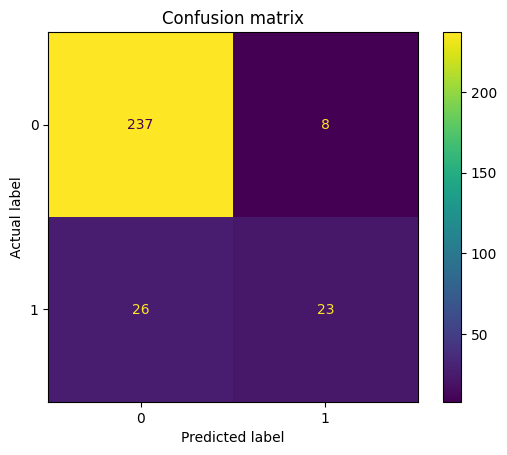

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# draw confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [39]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
# check accuracy, precision, recall, and f1

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

precision = precision_score(y_test, y_pred)
print(f"Precision Score: {precision:.4f}")

recall = recall_score(y_test, y_pred)
print(f"Recall Score (Sensitivity): {recall:.4f}")


f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

Overall Accuracy: 0.8844
Precision Score: 0.7419
Recall Score (Sensitivity): 0.4694
F1 Score: 0.5750


In [40]:
from sklearn.metrics import classification_report
# full report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       245
           1       0.74      0.47      0.57        49

    accuracy                           0.88       294
   macro avg       0.82      0.72      0.75       294
weighted avg       0.87      0.88      0.87       294



## Step 5: Finding the Most Important Factors

Finally, let's look inside the model to see what it learned. By checking the model's "coefficients," we can see which features had the biggest influence on the prediction.

* A **positive coefficient** means the feature increases the chance of an employee leaving.
* A **negative coefficient** means the feature decreases the chance of an employee leaving.

The bar chart below shows the top 10 factors that most heavily influence attrition.

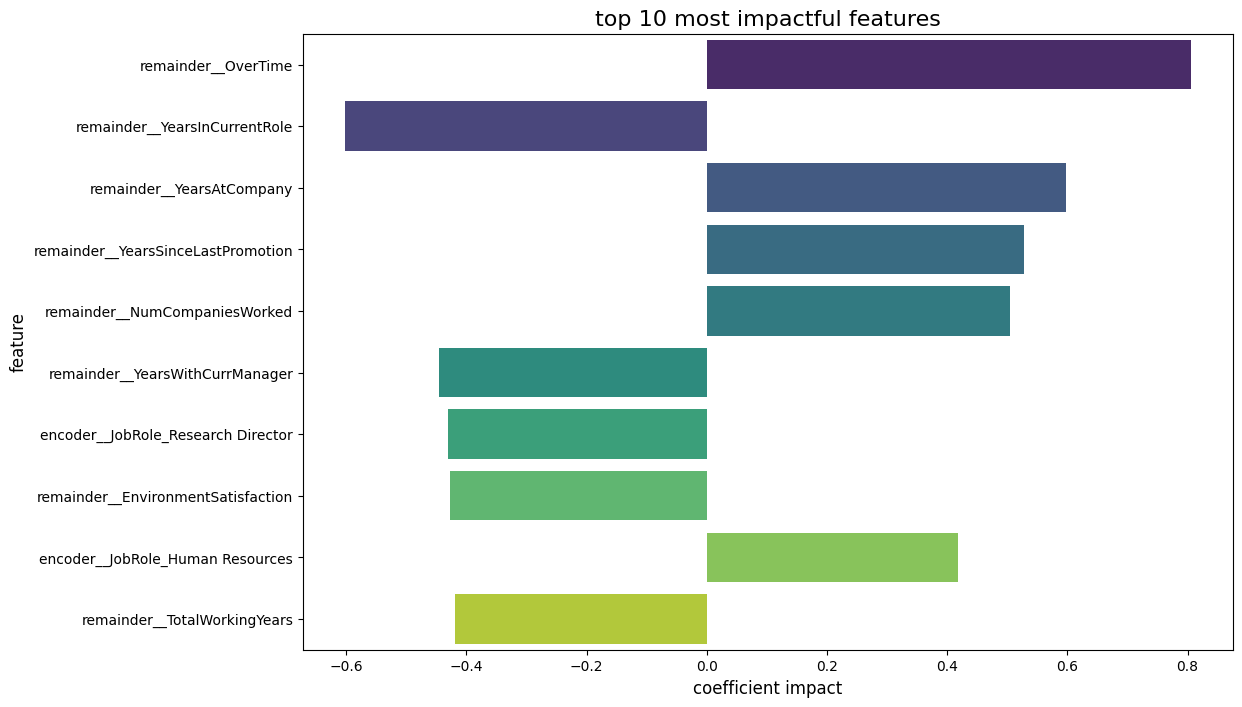

In [41]:
# get model coefficients
coef = logreg.coef_[0]

# get feature names after encoding
feat_name = ct.get_feature_names_out()

# create table of features and their effect
impDf = pd.DataFrame({'feature': feat_name, 'coefficient': coef})

# sort by biggest effect
impDf['abs_coefficient'] = impDf['coefficient'].abs()
impDf = impDf.sort_values(by='abs_coefficient', ascending=False)

# 5. Plot the top 10 most important features
plt.figure(figsize=(12, 8))

palette = sns.color_palette("viridis", n_colors=10)
sns.barplot(x='coefficient', y='feature', data=impDf.head(10), palette=palette)
plt.title('top 10 most impactful features', fontsize=16)
plt.xlabel('coefficient impact', fontsize=12)
plt.ylabel('feature', fontsize=12)
plt.show()